# Pondview pool — hourly arrival exploration

**Target: family *arrivals* per hour** — the count of sign-in lines that begin in a
given clock hour. This is **not occupancy**: the paper sheets record arrivals only,
never departures, so we can never know how many families were present at a moment.

The hour grid is built from `day_log.csv` (every open hour of every observed day), so
hours where the pool was open and *nobody came* are kept as true zeros — they carry
most of the bad-weather signal. This notebook looks for the structure a model could
exploit, and asks the one question that decides whether weather features are even
worth trusting: **is there enough weather variance in a four-week mid-summer window?**

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
})
BLUE, ORANGE, RED, GREEN = "#4C72B0", "#DD8452", "#C44E52", "#55A868"
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
MEASURABLE_IN = 0.01  # US convention: precip < 0.01" is a "trace", not measurable

df = pd.read_csv("../data/processed/hourly.csv", parse_dates=["datetime"])
df["date"] = df["datetime"].dt.normalize()
print(f"{len(df)} hourly rows | {df['date'].nunique()} observed days | "
      f"mean {df['arrivals'].mean():.2f} arrivals/hr | {(df['arrivals'] == 0).mean():.1%} zero-hours")
df.head()

173 hourly rows | 19 observed days | mean 6.74 arrivals/hr | 8.7% zero-hours


,datetime,arrivals,hour,day_of_week,is_weekend,temperature_2m,precipitation,relative_humidity_2m,cloud_cover,wind_speed_10m,date
0,2026-07-08 10:00:00,8,10,2,0,70.9,0.0,78,0,5.5,2026-07-08
1,2026-07-08 11:00:00,13,11,2,0,73.2,0.0,74,0,5.6,2026-07-08
2,2026-07-08 12:00:00,14,12,2,0,75.4,0.0,70,0,4.2,2026-07-08
3,2026-07-08 13:00:00,11,13,2,0,77.1,0.0,67,0,3.5,2026-07-08
4,2026-07-08 14:00:00,8,14,2,0,80.1,0.0,55,0,4.1,2026-07-08


## 1. Mean arrivals by hour of day
When do families show up?

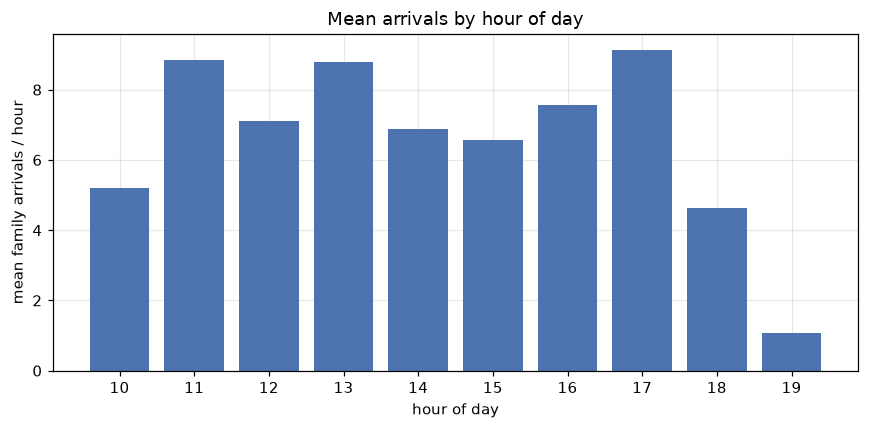

In [2]:
by_hour = df.groupby("hour")["arrivals"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_hour.index, by_hour.values, color=BLUE)
ax.set_xlabel("hour of day"); ax.set_ylabel("mean family arrivals / hour")
ax.set_title("Mean arrivals by hour of day"); ax.set_xticks(by_hour.index)
plt.tight_layout(); plt.show()

## 2. Mean arrivals by day of week
Weekends in orange.

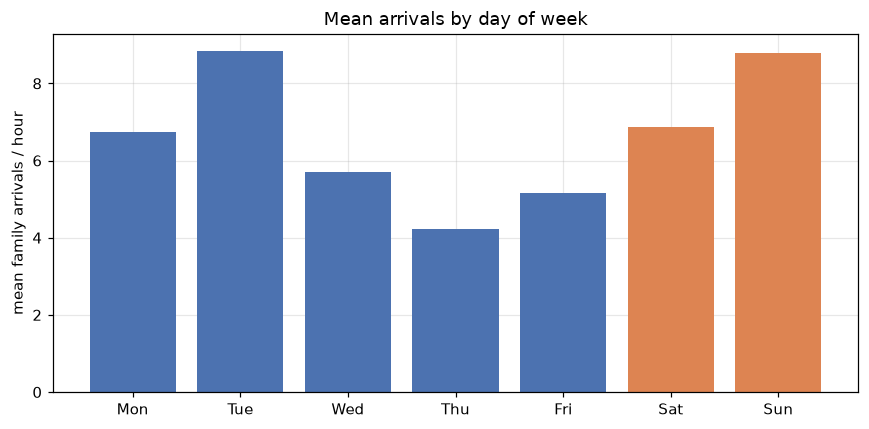

In [3]:
by_dow = df.groupby("day_of_week")["arrivals"].mean().reindex(range(7))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([DOW[d] for d in range(7)], by_dow.values,
       color=[BLUE if d < 5 else ORANGE for d in range(7)])
ax.set_ylabel("mean family arrivals / hour")
ax.set_title("Mean arrivals by day of week")
plt.tight_layout(); plt.show()

## 3. Arrivals vs temperature
Points coloured by whether the hour had measurable rain — the low outliers are almost
all wet hours, not cold ones, which previews where the weather signal actually lives.

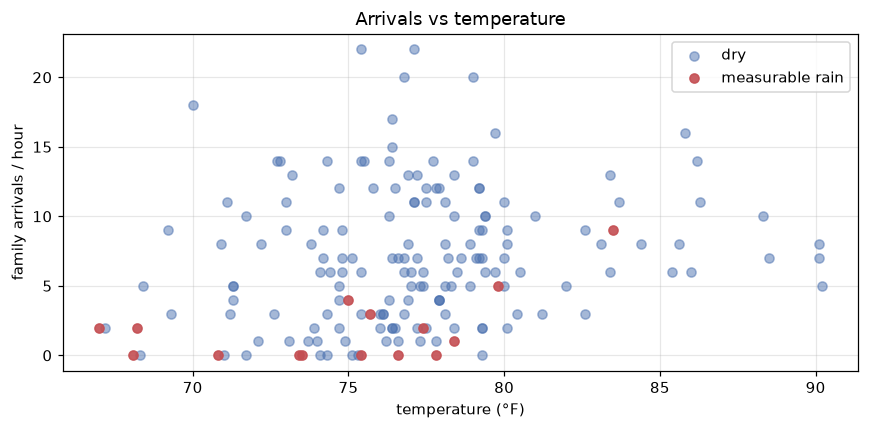

In [4]:
wet = df["precipitation"] >= MEASURABLE_IN
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df.loc[~wet, "temperature_2m"], df.loc[~wet, "arrivals"],
           alpha=0.5, color=BLUE, label="dry")
ax.scatter(df.loc[wet, "temperature_2m"], df.loc[wet, "arrivals"],
           alpha=0.9, color=RED, label="measurable rain")
ax.set_xlabel("temperature (°F)"); ax.set_ylabel("family arrivals / hour")
ax.set_title("Arrivals vs temperature"); ax.legend()
plt.tight_layout(); plt.show()

## 4. Arrivals across the season
Line breaks are unobserved days — the pool was closed, or the sign-in sheet was lost.
Those gaps are why we drive the hour grid from `day_log`, not from a continuous date
range: we only ever model days we actually observed.

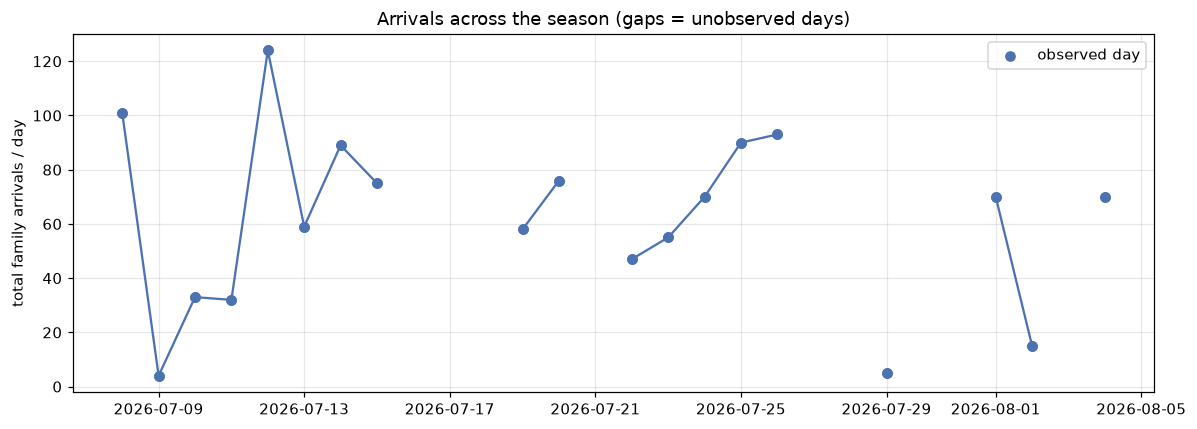

In [5]:
daily = df.groupby("date")["arrivals"].sum()
full = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily_full = daily.reindex(full)  # NaN on missing days -> matplotlib breaks the line
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily_full.index, daily_full.values, marker="o", color=BLUE)
ax.scatter(daily.index, daily.values, color=BLUE, zorder=3, label="observed day")
ax.set_ylabel("total family arrivals / day")
ax.set_title("Arrivals across the season (gaps = unobserved days)")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Hourly profile: weekday vs weekend
This is precisely the structure the **baseline** exploits — mean arrivals by
(hour × is_weekend). Any real model has to beat *this* picture to earn its place.

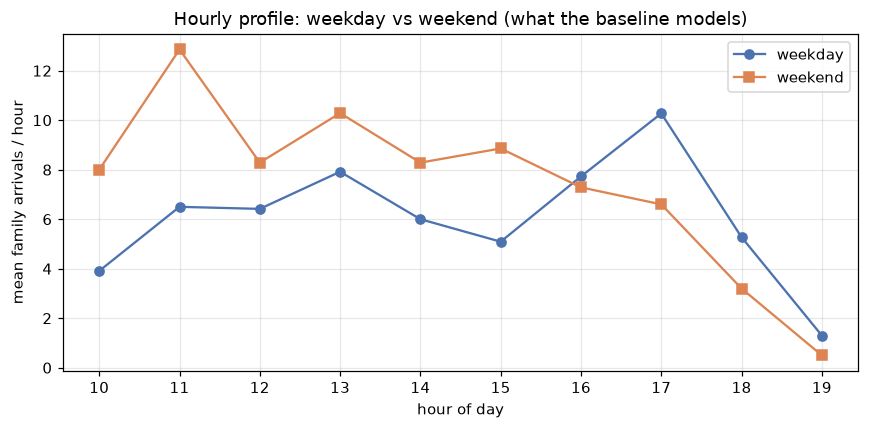

In [6]:
profile = df.groupby(["hour", "is_weekend"])["arrivals"].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(profile.index, profile[0], marker="o", color=BLUE, label="weekday")
ax.plot(profile.index, profile[1], marker="s", color=ORANGE, label="weekend")
ax.set_xlabel("hour of day"); ax.set_ylabel("mean family arrivals / hour")
ax.set_title("Hourly profile: weekday vs weekend (what the baseline models)")
ax.set_xticks(profile.index); ax.legend()
plt.tight_layout(); plt.show()

## 6. Dry vs measurable-rain hours
The mean gap looks dramatic, but the raw points (overlaid) show how *few* wet hours
there are — the effect rests on a thin sample. That caveat matters more than the gap.

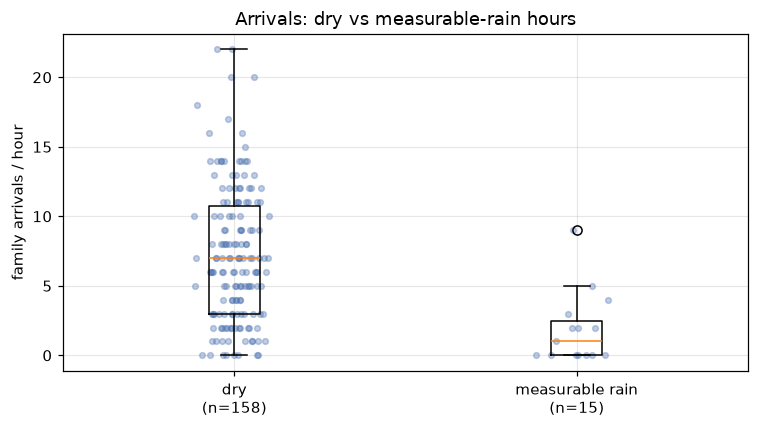

In [7]:
groups = [df.loc[~wet, "arrivals"].values, df.loc[wet, "arrivals"].values]
labels = [f"dry\n(n={(~wet).sum()})", f"measurable rain\n(n={wet.sum()})"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(groups, tick_labels=labels)
rng = np.random.default_rng(0)
for i, g in enumerate(groups, start=1):
    ax.scatter(rng.normal(i, 0.05, len(g)), g, alpha=0.35, color=BLUE, s=14)
ax.set_ylabel("family arrivals / hour")
ax.set_title("Arrivals: dry vs measurable-rain hours")
plt.tight_layout(); plt.show()

## 7. Which weather signals track arrivals?
Correlation of each retained weather feature with arrivals. Note it is **humidity**,
not raw temperature, that leads — a hot muggy afternoon suppresses turnout more than a
merely warm one, and humidity partly proxies the rain we barely observe.

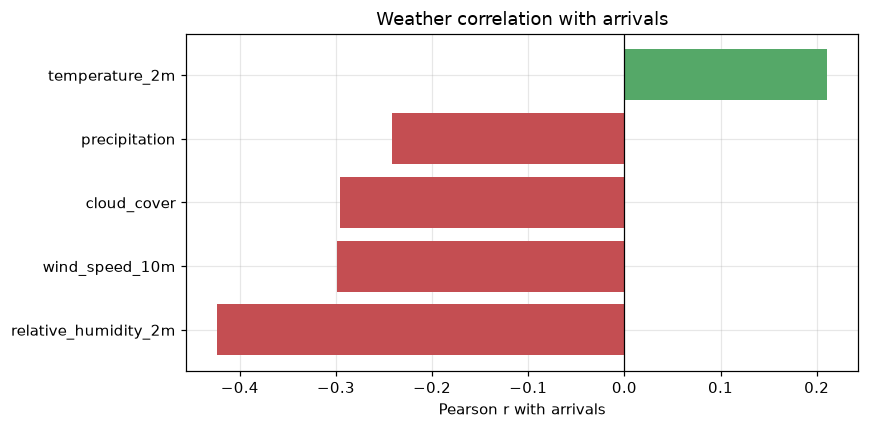

In [8]:
weather_cols = ["temperature_2m", "precipitation", "relative_humidity_2m",
                "cloud_cover", "wind_speed_10m"]
corrs = df[weather_cols].apply(lambda c: c.corr(df["arrivals"])).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(corrs.index, corrs.values, color=[RED if v < 0 else GREEN for v in corrs.values])
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Pearson r with arrivals")
ax.set_title("Weather correlation with arrivals")
plt.tight_layout(); plt.show()

## The binding constraint: how much weather variance is there?

In [9]:
n_measurable = int((df["precipitation"] >= MEASURABLE_IN).sum())
n_trace = int((df["precipitation"] > 0).sum())
n_heavy = int((df["precipitation"] >= 0.05).sum())
print(f"Hours with MEASURABLE precipitation (>= {MEASURABLE_IN}\"): "
      f"{n_measurable} of {len(df)} ({n_measurable / len(df):.1%})")
print(f"  any trace (> 0\"):        {n_trace} hours")
print(f"  >= 0.05\" in the hour:    {n_heavy} hours")
print(f"  total precip, all open hours: {df['precipitation'].sum():.2f} inches")
print(f"  mean arrivals  dry: {df.loc[~wet, 'arrivals'].mean():.2f}  "
      f"|  wet: {df.loc[wet, 'arrivals'].mean():.2f}")

Hours with MEASURABLE precipitation (>= 0.01"): 15 of 173 (8.7%)
  any trace (> 0"):        46 hours
  >= 0.05" in the hour:    3 hours
  total precip, all open hours: 0.60 inches
  mean arrivals  dry: 7.20  |  wet: 1.87


## What this means for modeling

- **Strong, learnable structure exists in time**: a clear hourly profile (evening
  fall-off after ~17:00) and a weekend lift. This is what the baseline already captures.
- **Weather variance is thin.** Only ~15 of 173 open hours had measurable rain, and
  the effect is concentrated in a handful of days. The dry-vs-wet gap is large but
  rests on a small sample, so any weather-driven gain must be read with caution and
  validated by **leave-one-day-out** CV (so a single rainy afternoon can't leak across
  the split). If weather features barely beat the time-only baseline, that is a
  legitimate, honest finding for this window — not a bug to tune away.
- Among weather signals, **humidity** — not temperature — tracks arrivals most, with
  precipitation and cloud/wind close behind, all pointing the same "nice day" direction.